Starting Stochastic Reconfiguration minimiser...
Iteration number: 99
Time elapsed: 43.6060s
Final derivative: [-0.00564008  0.00313981 -0.00026692]
Starting gradient descent minimiser...
Iteration number: 99
Time elapsed: 43.4320s
Final derivative: [ 0.11509115  0.01660772 -0.00657498]
Starting RMSProp gradient descent minimiser...
Iteration number: 99
Time elapsed: 43.2835s
Final derivative: [ 0.01149242 -0.0023091  -0.00023626]
Starting quasi-newton minimiser...
Iteration number: 99
Time elapsed: 86.3332s
Final derivative: [ 0.55868583  0.01351081 -0.0035836 ]
Starting quasi-newton minimiser...


/Users/louis/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Computer Science/Computational Physics/Project/modules/minimisers.py:762: RuntimeWarning: divide by zero encountered in scalar divide
  temp = 1.0 / np.dot(gamma, delta)
/Users/louis/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Computer Science/Computational Physics/Project/modules/minimisers.py:765: RuntimeWarning: invalid value encountered in multiply
  (I - temp * np.outer(delta, gamma)
/Users/louis/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Computer Science/Computational Physics/Project/modules/minimisers.py:766: RuntimeWarning: invalid value encountered in multiply
  ) @ G @ (I - temp * np.outer(gamma, delta))
/Users/louis/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Computer Science/Computational Physics/Project/modules/minimisers.py:767: RuntimeWarning: invalid value encountered in multiply
  + temp * np.outer(delta, delta)
/Users/louis/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Comp

Iteration number: 99
Time elapsed: 80.3194s
Final derivative: [nan nan nan]
starting simulated annealing...
Time elapsed: 85.1624s
Final Energy: -1.1124666332896365
Failed to save results as JSON. Skipping...

FINAL RESULTS SUMMARY


KeyError: 'energy_error'

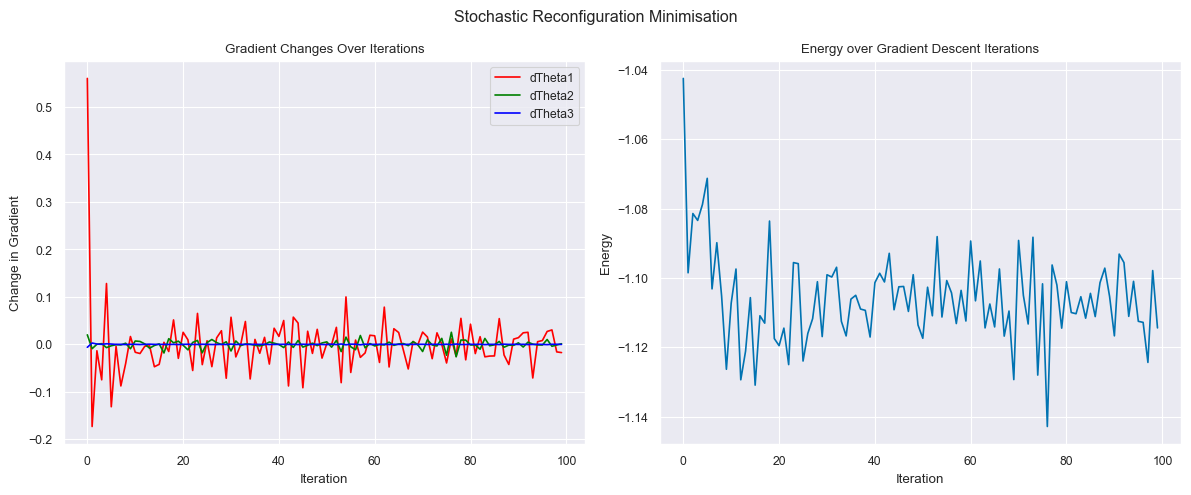

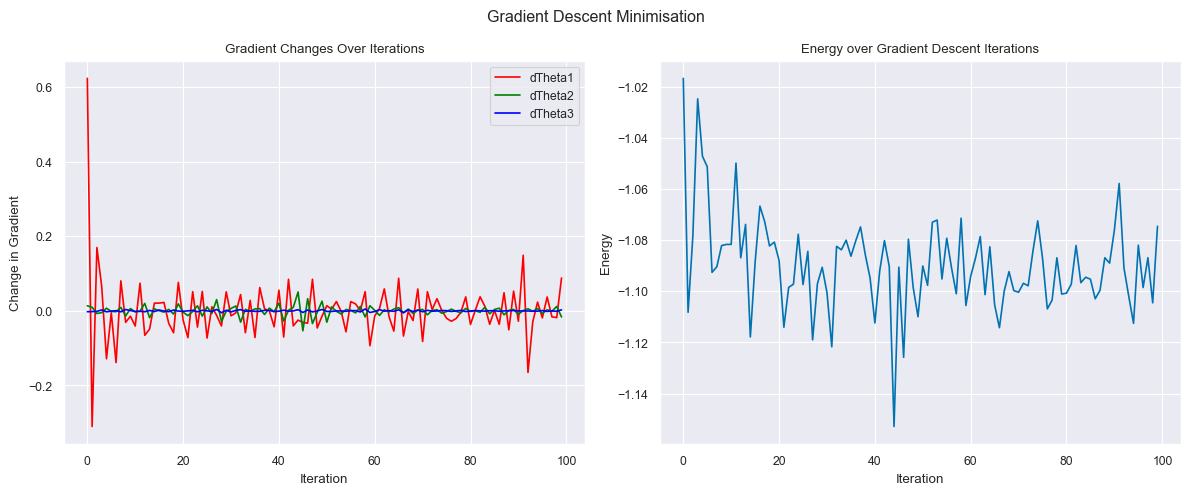

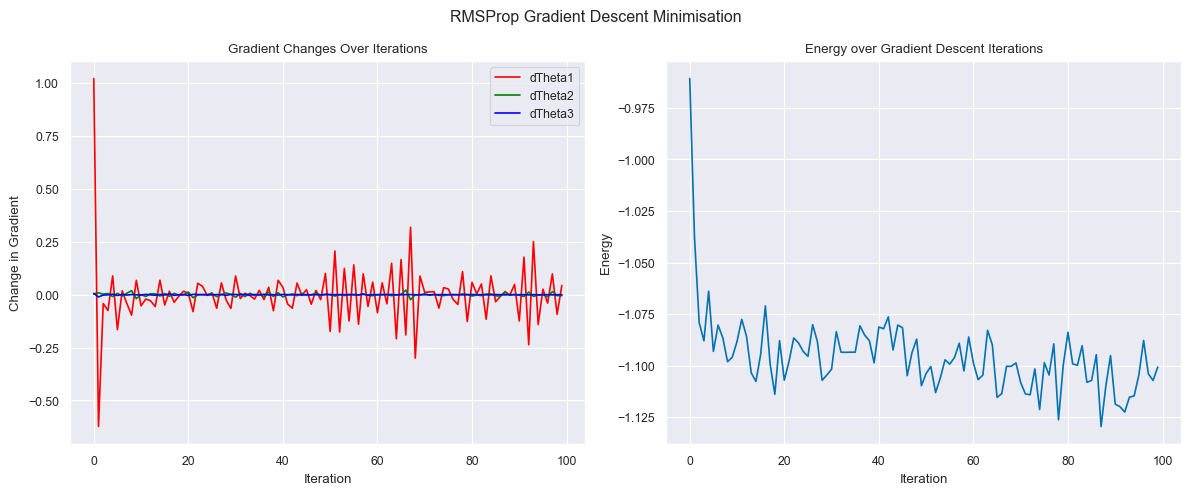

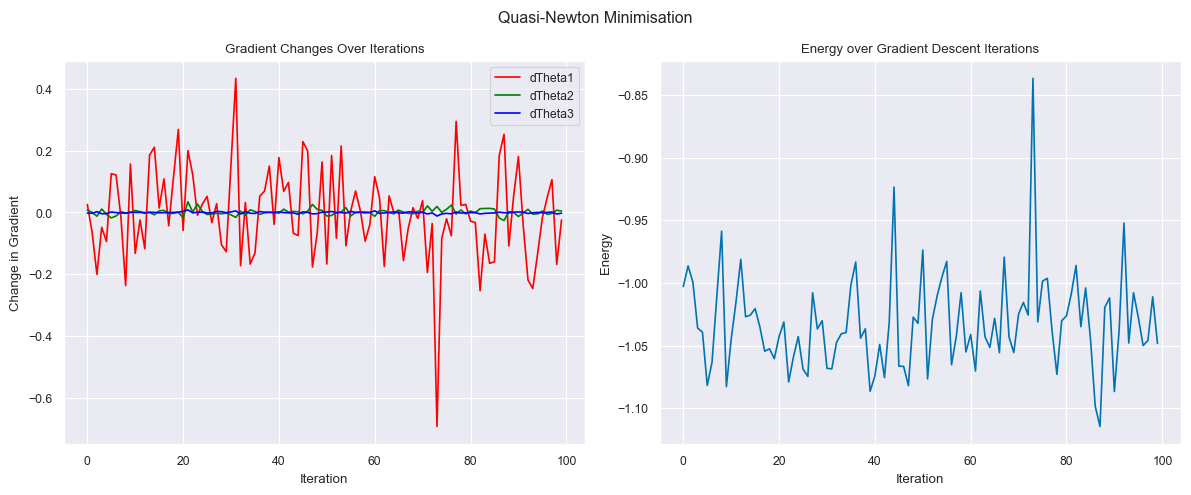

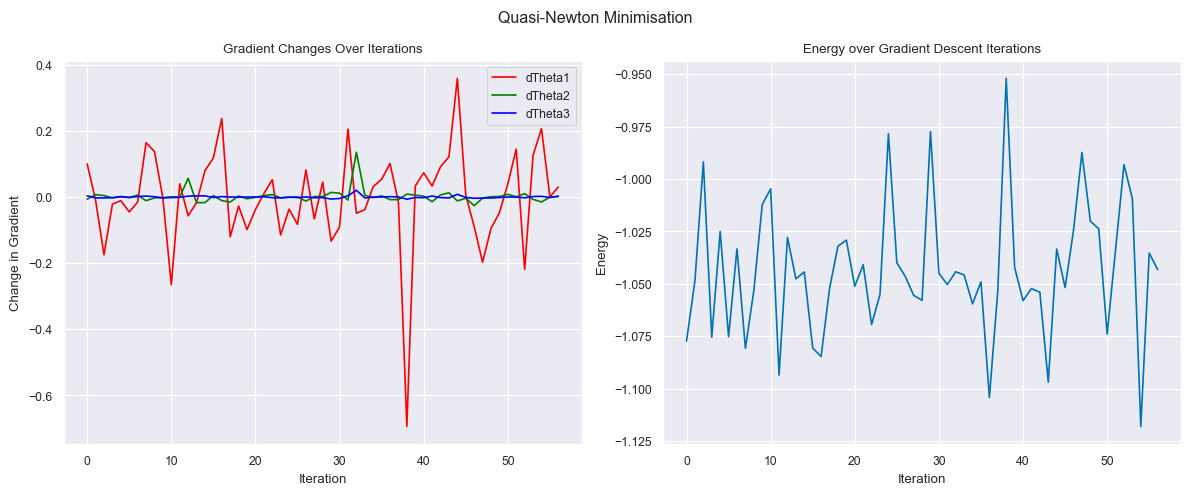

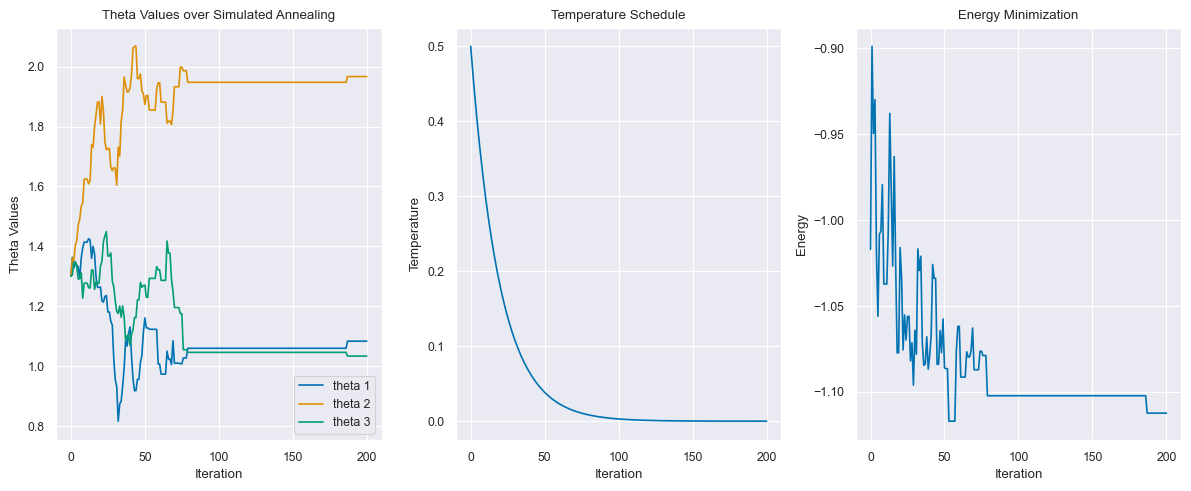

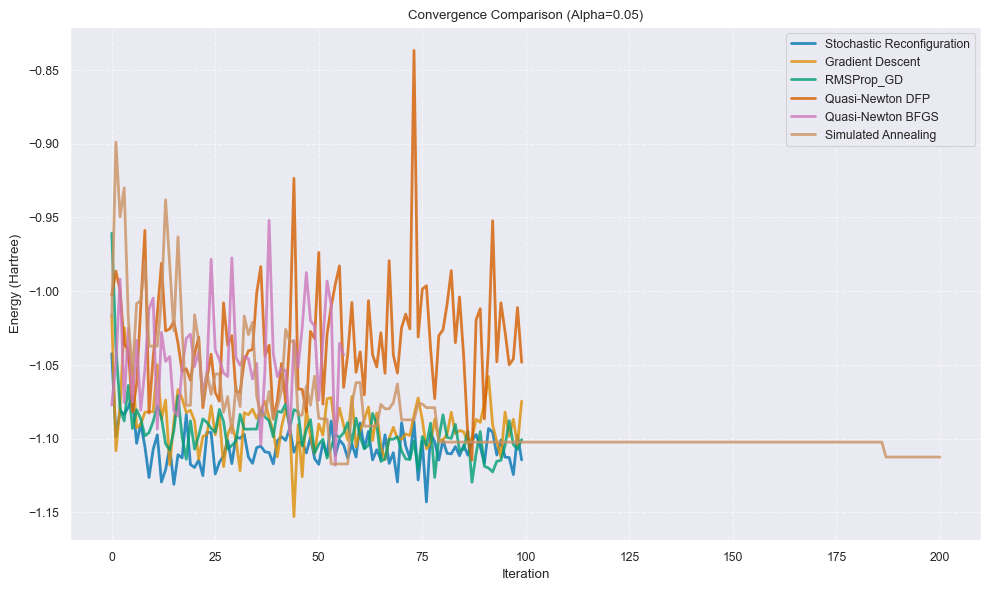

In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as minimisers
import matplotlib.pyplot as plt


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s,
                   timestep=0.5, xmin=-10., xmax=10., detail=True)

    # samples = metropolis_hastings(
    #     wrapper, f_prop='gaussian', x_0=x_0, xmax=10., xmin=-10., N=N_s, kwrgs={
    #         'sigma': 0.7}, detail=True)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=False)
    plt.show()


def test_SR():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    N_s = 100000
    thetas_0 = [1.3] * 3  #  for minimiser
    alphas = [.1]  #  np.linspace(0.1, 1., 20)
    for alpha in alphas:
        theta_min, E_min, results = minimisers.stochastic_reconfiguration(q1, q2, x_0=thetas_0,
                                                                          alpha=alpha, stop_tol=0.005, N_s=N_s, sampling="MH", detail=True, trace=True, max_iter=30)

        print(f"minimum theta: {theta_min}, minimum energy: {E_min}")
        results['figure'].show()


def test_QN():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    N_s = 100000
    thetas_0 = [0.5] * 3  #  for minimiser
    theta_min, E_min, results = minimisers.quasi_newton(q1, q2, x_0=thetas_0,
                                                        alpha=0.1, stop_tol=0.005, N_s=N_s, sampling="MH", max_iter=50, method='DFP', detail=True, trace=True)

    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")
    results['figure'].show()
    print(f"Minimum Theta : {results['final_state']['parameters']}")
    print(f"Minimum Energy: {results['final_state']['energy']:.6f}")


def test_minimisers_convergence(alpha=0.1):
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]
    N_s = 10000
    thetas_0 = [1.3] * 3
    stop_tol = None

    results = {}

    _, _, results['Stochastic Reconfiguration'] = minimisers.stochastic_reconfiguration(
        q1, q2, x_0=thetas_0, alpha=alpha, stop_tol=stop_tol, N_s=N_s, detail=True, max_iter=100
    )

    _, _, results['Gradient Descent'] = minimisers.gradient_descent(
        q1, q2, x_0=thetas_0, alpha=alpha, stop_tol=stop_tol, N_s=N_s, detail=True, max_iter=100
    )

    _, _, results['RMSProp_GD'] = minimisers.RMSProp_GD(
        q1, q2, x_0=thetas_0, alpha=alpha, stop_tol=stop_tol, forgetting=0.9, N_s=N_s, detail=True, max_iter=100
    )

    _, _, results['Quasi-Newton DFP'] = minimisers.quasi_newton(
        q1, q2, x_0=thetas_0, alpha=alpha, stop_tol=stop_tol, N_s=N_s, detail=True, max_iter=100, method='DFP'
    )

    _, _, results['Quasi-Newton BFGS'] = minimisers.quasi_newton(
        q1, q2, x_0=thetas_0, alpha=alpha, stop_tol=stop_tol, N_s=N_s, detail=True, max_iter=100, method='BFGS'
    )

    _, _, results['Simulated Annealing'] = minimisers.simulated_annealing(
        q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True
    )

    plt.figure(figsize=(10, 6))

    for method_name, result_hash in results.items():
        energies = result_hash['history']['energies']
        iterations = range(len(energies))
        plt.plot(iterations, energies, label=method_name,
                 linewidth=2, alpha=0.8)

    plt.xlabel("Iteration")
    plt.ylabel("Energy (Hartree)")
    plt.title(f"Convergence Comparison (Alpha={alpha})")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"convergence_comparison_alpha_{alpha}.png")

    def serialise(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.float64, np.int64)):
            return obj.item()
        if isinstance(obj, dict):
            return {k: serialise(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [serialise(v) for v in obj]
        return obj

    try:
        import json
        with open(f"convergence_results_alpha_{alpha}.json", 'w') as f:
            json.dump(serialise(results), f, indent=4)
    except:
        print("Failed to save results as JSON. Skipping...")

    print("\n" + "="*50)
    print("FINAL RESULTS SUMMARY")
    print("="*50)

    for method_name, result_hash in results.items():
        final_theta = result_hash['final_state']['parameters']
        final_energy = result_hash['final_state']['energy']
        energy_error = result_hash['final_state']['energy_error']

        print(f"{method_name}")
        print(f"Minimum Theta : {final_theta}")
        print(f"Minimum Energy: {final_energy:.6f}")
        print(f"Energy Error  : {energy_error:.6f}")
        print("-" * 30)


def ground_state_energies():
    Ns = 10000
    r_0 = np.linspace(0.5, 3., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    thetas = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        # theta_min, E_min = minimisers.simulated_annealing(
        #     q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        # theta_min, E_min = minimisers.quasi_newton(
        #     q1, q2_i, x_0=thetas_0, alpha=0.1, stop_tol=0.005, N_s=Ns, detail=False, max_iter=100)

        theta_min, E_min = minimisers.stochastic_reconfiguration(
            q1, q2_i, x_0=thetas_0, alpha=0.2, stop_tol=0.005, N_s=Ns, detail=False, sampling="sMALA", max_iter=100)
        thetas.append(theta_min)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"SA_output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"SA_output_{Ns}.txt", [energies, r_0[:len(energies)], thetas])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    alphas = [0.05, 0.1, 0.3, 0.01, 0.2]
    for alpha in alphas:
        test_minimisers_convergence(alpha)
    # test_SR()